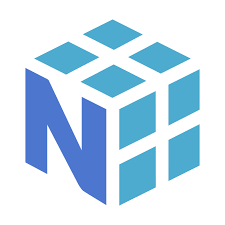

# Welcome to this NumPy Tutorial
NumPy, which is short for "Numbers Python", is a library for efficiently processing large volumes of numerical data in Python.  Like pandas, it is extremely important for machine learning, particularly for computer vision.  

In this tutorial, we will show you the power of NumPy, and in particular, we will look at some of the properties of arrays, matrices, and some common NumPy operations.

## Import Block
Typically you will see `import numpy as np` written, but this is just convention.  You can write this import statement in whatever way works best for you.

In [2]:
# Import NumPy
import numpy as np

# We will use os to find specific paths in our directories
import os

# Use for timing computation
import time

# Use for plotting
import matplotlib.pyplot as plt

## Intro to nd-arrays
The **nd-array**, or n-dimensional array, data structure is the core element of the numpy library.  In one dimension, they are very similar to the Python `list` data structure.  In two dimensions, you can think of these as nd-arrays as being similar to a `list` of `lists`.

### Why Numpy Arrays?  Comparing Run Times


The main difference between a native Python `list` and a numpy `nd-array` is that an `nd-array` is much more computationally efficient.  Run the code block and let's see just how much more efficient it is.

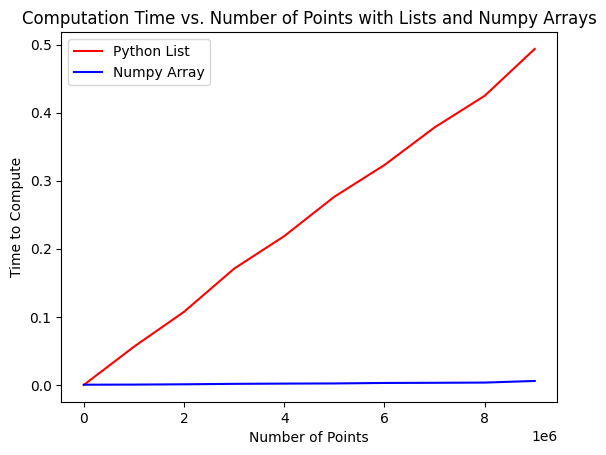

List Times 
 [1.9073486328125e-06, 0.05608510971069336, 0.1074075698852539, 0.1707921028137207, 0.2185981273651123, 0.2764413356781006, 0.3230311870574951, 0.37825751304626465, 0.42470622062683105, 0.49361157417297363]
Numpy Array Times 
 [0.00032520294189453125, 0.0004787445068359375, 0.0009145736694335938, 0.001580953598022461, 0.0019440650939941406, 0.0021750926971435547, 0.0028924942016601562, 0.00313568115234375, 0.003444671630859375, 0.005831003189086914]


In [3]:
# Store time to compute for Python list and numpy nd-array
list_times = []
nd_array_times = []
num_points = []

for i in range(10,10000010,1000000):

    num_points.append(i)

    python_list = [j for j in range(i)]
    t_list_start = time.time()
    total = 0
    for elt in python_list:
        total += elt
    t_list_end = time.time()
    list_times.append(t_list_end - t_list_start)

    np_array = np.arange(i)
    t_array_start = time.time()
    total = np.sum(np_array)
    t_array_end = time.time()
    nd_array_times.append(t_array_end - t_array_start)

# Plot both
plt.plot(num_points, list_times, color="r", label="Python List")
plt.plot(num_points, nd_array_times, color="b", label="Numpy Array")
plt.legend()
plt.xlabel("Number of Points")
plt.ylabel("Time to Compute")
plt.title("Computation Time vs. Number of Points with Lists and Numpy Arrays")
plt.show()

# Show the times
print("List Times \n", list_times)
print("Numpy Array Times \n", nd_array_times)

As we can see, numpy is significantly faster for **vector** and **matrix** operations, such as adding an array of numbers.  We will be using numpy a lot in class to speed up our code.

### Basic Operations with **nd-arrays**
Let's start working with these data structures!

#### Creating Numpy Arrays

In [4]:
# Can create numpy arrays using the following function
A = np.array([1, 2, 3, 4])
print("A is an np vector", A)

# Can also create numpy arrays from lists!
B = [1, 2, 3, 4]  # List in Python
C = np.array(B)
print("C is an np vector", C)

# Elements do not have to be integers
D = np.array([0.01, -5.7, 10.2, 0.000076])
print("D is", D)


A is an np vector [1 2 3 4]
C is an np vector [1 2 3 4]
D is [ 1.00e-02 -5.70e+00  1.02e+01  7.60e-05]


#### Dimensionality, Row, and Column Vectors
We can view the dimension of an np-array by calling "array.shape"

We can think of nd-arrays as vectors (in one dimension), matrices (in two dimensions), or tensors (any dimension). Below you can see how we create row and column vectors.

In [5]:
# Create a "row vector":
E = np.array([[1, 2, 3, 4]])
print("E is a row vector", E)

# We can get the shape of a nd-array through the "shape" attribute
print("Shape of E is: ", E.shape)

# Now let's create a "column vector"
F = np.array([[1], [2], [3], [4]])
print("F is a column vector", F)

# We can get the shape of a nd-array through the "shape" attribute
print("Shape of F is:", F.shape)

# We can also change a row vector to a column vector through taking the transpose!
G = np.array(E).T  # Take the transpose with ".T"
print("G is:", G)

# We can get the shape of a nd-array through the "shape" attribute
print("Shape of G is:", G.shape)

print("F and G have the same shape!")

E is a row vector [[1 2 3 4]]
Shape of E is:  (1, 4)
F is a column vector [[1]
 [2]
 [3]
 [4]]
Shape of F is: (4, 1)
G is: [[1]
 [2]
 [3]
 [4]]
Shape of G is: (4, 1)
F and G have the same shape!


#### Matrices in Numpy
Row vectors have the first dimension equal to 1 and column vectors have second dimension equal to 1.

Matrices can have any dimension.  Numpy has a great amount of functionality built in for handling computations and transformations on matrices.  Let's see this below.

In [6]:
# Create the array
H = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print("H is: \n \n", H)

# We can get the shape of a nd-array through the "shape" attribute
print("\n Shape of H is: ", H.shape)

# We can also use the reshape function to change the dimensions of a nd-array
print("Reshaped H into 1 x 9 column vector: \n ",  H.reshape((1, 9)))
print("Reshaped H into 9 x 1 column vector: \n", H.reshape((9, 1)))

H is: 
 
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

 Shape of H is:  (3, 3)
Reshaped H into 1 x 9 column vector: 
  [[1 2 3 4 5 6 7 8 9]]
Reshaped H into 9 x 1 column vector: 
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


**Check Yourself Exercise**

Try creating a np array row vector that has shape (1, 20) and elements 0 through 19. Double check the shape at the end.

*Hint* try creating a list with the elements you want first and then turn it into an np array.

In [7]:
# TODO - make the np array with shape (1,20) and elements [0,1,2,...,19]

#### Some Common NP Operations
We can now explore some useful operations

##### 1. Math Operations in Numpy

Below we will see examples of addition and subtraction

In [8]:
# Create two arrays
N = np.array([[1, 2], [3, 4]])
P = np.array([[5, 6], [7, 8]])
print("N is: \n", N)
print("P is: \n", P)

# Perform addition
print("Addition of N + P: \n", N + P)

# Perform subtraction
print("Subtraction of N - P:\n", N-P)

N is: 
 [[1 2]
 [3 4]]
P is: 
 [[5 6]
 [7 8]]
Addition of N + P: 
 [[ 6  8]
 [10 12]]
Subtraction of N - P:
 [[-4 -4]
 [-4 -4]]


2. Different Types of Multiplication

There are two main types of multiplication with matrices. Matrix multiplication which we're familiar with from [math](https://en.wikipedia.org/wiki/Matrix_multiplication).

The other type is element-wise multiplication which just multiplies each corresponding element of the matrices independently (read more [here](corresponding)).

In [9]:
N = np.array([[1, 2], [3, 4]])
P = np.array([[5, 6], [7, 8]])
print("N is: \n", N)
print("P is: \n", P)

# Element-wise multiplication
print("\nElement-wise multiplication:\n", N*P)

# Matrix multiplication
print("\nMatrix multiplication:\n", np.dot(N, P))

# A shorthand for matrix multiplication is @
print("\nMatrix multiplication:\n", N@P)

N is: 
 [[1 2]
 [3 4]]
P is: 
 [[5 6]
 [7 8]]

Element-wise multiplication:
 [[ 5 12]
 [21 32]]

Matrix multiplication:
 [[19 22]
 [43 50]]

Matrix multiplication:
 [[19 22]
 [43 50]]


###### 3. np.sum(Array, axis = ?)
This function computes the sum of a given array over the axis given by the (optional) axis argument.  If no argument is provided for axis, this function sums over all the elements in the array.  A diagram for axes is provided below:

![Axis Diagram](https://i.stack.imgur.com/h1alT.jpg)

As we can see from the diagram above, summing over the rows corresponds to "axis = 1", while summing over the columns corresponds to "axis = 0".  This is consistent with how numpy computes shape - the 0 index of array.shape corresponds to the length of/over the columns, and the 1 index of array.shape corresponds to the length of/over the rows.  We will investigate how axis affects our output below.

In [10]:
# Create the 2D array
J = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print("J is: \n", J)

# Now let's compute sums over this array!
K = np.sum(J, axis=None)  # No axis
print("Sum over no axis:", K)

L = np.sum(J, axis=0)  # Axis = 0
print("Sum over axis 0", L)

M = np.sum(J, axis=1)  # Axis = 1
print("Sum over axis 1", M)

J is: 
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Sum over no axis: 45
Sum over axis 0 [12 15 18]
Sum over axis 1 [ 6 15 24]


3. Comparison operations

We can also do comparison operations between arrays. For example, below we check the equality of elements.

In [11]:
N = np.array([[1, 2], [3, 4]])
P = np.array([[5, 2], [7, 4]])

print("The equality of N and P is:\n", N==P)

# Note the values of False and True can be treated as 1's and 0's, so we can take the sum
print("Sum of the equality matrix:", np.sum(N == P))

The equality of N and P is:
 [[False  True]
 [False  True]]
Sum of the equality matrix: 2


##### 4. Generating Arrays of Arbitrary Size with Numpy
Another great thing about numpy is that it has many functions for creating arrays of any size.

In [12]:
# Create a matrix of all zeros
T = np.zeros((2, 2, 2))
print("T is: \n", T)

# Create a matrix of all ones
U = np.ones((7, 4))
print("U is: \n", U)

T is: 
 [[[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]]
U is: 
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


**Exercise**

To try your hand at using these np operations, we will work through a very common ML scenario of calculating the accuracy of a model.

We have some input data and labels represented as np arrays. The model is an np array, and we will make a prediction by matrix multiplying the model by the input.

You should compute the percentage of correct predicitons (that is, predictions that match the labels).

In [13]:
input_data = np.array([[1,2,2], [2,3,4]])
true_labels = np.array([[1,1,0]]) # 0s and 1s represent labels of False and True
model = np.array([[2,-1]])

# TODO - make a predictions array by matrix multiplying the model and the input data. It should be [[0,1,0]]

# TODO - then calculate the number of correct predictions by checking the equality of the predictions
#  with the labels

# TODO - finally compute the percentage of correct predictions. This should be .66


##### 5. Generating Data Using NumPy
Numpy also has powerful functionality built in for sampling random variables, vectors, and matrices of any size from different probability distributions.

V is: 
 [[0.40949481 0.61483181 0.11440044]
 [0.66528577 0.32230258 0.70012489]]
W is: 
 0.09853484834389903
Z is: 
 [[17.78758841 13.38700553]
 [ 4.72920708 19.84454528]]
Z is: 
 [['7' '7' '8']
 ['H' '8' 'H']
 ['7' '7' 'H']]


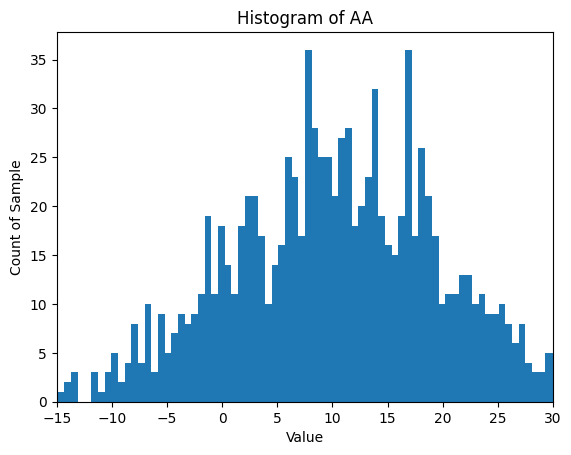

Mean of sampled points is: 10.518670548695649, 
 Variance is: 95.88347585693808, 
 Standard deviation is: 9.792010817852383 



In [14]:
#np.random.random(size=None): Samples uniformly from [0,1).
#Can sample a single number, or a vector/matrix/tensor according to the size argument.
V = np.random.random(size=(2,3))
print("V is: \n", V)
W = np.random.random(size=None) #generates a single number
print("W is: \n", W)

#np.random.uniform(low = , high = , size= ) now lets you choose the range [low, high)
#argument size remains the same
X = np.random.uniform(low=0, high=25, size=(2,2))
print('Z is: \n', X)

#np.random.choice(array) samples uniformly from elements in a given array argument
Y = np.array([7, 'H', 8, 13]) #you can even add strings

Z = np.random.choice(Y, size=(3,3))
print("Z is: \n", Z)

#numpy.random.normal(loc=0.0, scale=1.0, size=None) samples from the Gaussian distribution, with
# loc = mean and scale = standard deviation.  Can sample a single number, or a vector/matrix/tensor
# according to the size argument.
AA = np.random.normal(loc=10, scale=10, size=(1000))
plt.hist(AA, bins=100)
plt.xlim(-15, 30)
plt.title("Histogram of AA")
plt.xlabel("Value")
plt.ylabel("Count of Sample")
plt.show()

#NumPy also provides some statistical functions as well
mean = np.mean(AA)
var = np.var(AA)
std = np.std(AA)
print("Mean of sampled points is: %s, \n Variance is: %s, \n Standard deviation is: %s \n" % (mean, var, std))

**Exercise**

Try your hand at generating data.

Suppose you have 10 people that pick between option 'A' and 'B' and do so independently of each other.

You estimate that the probability of choosing 'A' is 50%, and of choosing 'B' is 25%, however, a person can also decide to pick neither. Generate an array that represents the *choice* of each individual

In [15]:
#Generate the array.
#How would you repesent choosing 'neither'?


#How many individuals choose 'A'? (hint: you might np.where useful)

#Who are these individuals? (i.e. their index)

## Conclusions and Takeaways

Numpy is a powerful package for vector and matrix computation in Python.  In this tutorial, we've explored the following concepts:

1. Numpy nd-arrays

2. Axis, Shape, and Dimension

3. NP Operations

3. Generating Data


This tutorial covers a microscopic fraction of all the functionality built into [numpy](https://numpy.org/).  We highly encourage you to explore this library further!